# Предсказание конверсии - СберАвтоподписка

Задача: по данным о сессии предсказать вероятность целевого действия (заявка, звонок, диалог).  
Данные: `ga_sessions.csv` + `ga_hits.csv`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)

import lightgbm as lgb
import shap
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = os.path.join("..", "data")
MODELS_DIR = os.path.join("..", "models")
os.makedirs(MODELS_DIR, exist_ok=True)

In [2]:
pd.set_option('display.max_rows', None)

## 1. Загрузка данных и первичный анализ

In [3]:
sessions = pd.read_csv(
    os.path.join(DATA_DIR, "ga_sessions.csv"),
    dtype={
        "session_id": str, "client_id": str,
        "visit_date": str, "visit_time": str,
        "utm_source": str, "utm_medium": str,
        "utm_campaign": str, "utm_keyword": str,
        "device_category": str, "device_os": str,
        "device_brand": str, "device_model": str,
        "device_screen_resolution": str, "device_browser": str,
        "geo_country": str, "geo_city": str,
    }
)
print(f"ga_sessions: {sessions.shape}")

HIT_COLS = [
    "session_id", "hit_date", "hit_time", "hit_number",
    "hit_page_path", "event_category", "event_action", "event_label", "event_value"
]
hits = pd.read_csv(
    os.path.join(DATA_DIR, "ga_hits.csv"),
    usecols=HIT_COLS,
    dtype={
        "session_id": str, "hit_date": str, "hit_time": str,
        "hit_page_path": str, "event_category": str,
        "event_action": str, "event_label": str,
    }
)
print(f"ga_hits: {hits.shape}")

sessions.head(3)

ga_sessions: (1860042, 18)
ga_hits: (15726470, 9)


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk


In [4]:
sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype
---  ------                    -----
 0   session_id                str  
 1   client_id                 str  
 2   visit_date                str  
 3   visit_time                str  
 4   visit_number              int64
 5   utm_source                str  
 6   utm_medium                str  
 7   utm_campaign              str  
 8   utm_adcontent             str  
 9   utm_keyword               str  
 10  device_category           str  
 11  device_os                 str  
 12  device_brand              str  
 13  device_model              str  
 14  device_screen_resolution  str  
 15  device_browser            str  
 16  geo_country               str  
 17  geo_city                  str  
dtypes: int64(1), str(17)
memory usage: 255.4 MB


In [5]:
hits.info()

<class 'pandas.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   session_id      str    
 1   hit_date        str    
 2   hit_time        str    
 3   hit_number      int64  
 4   hit_page_path   str    
 5   event_category  str    
 6   event_action    str    
 7   event_label     str    
 8   event_value     float64
dtypes: float64(1), int64(1), str(7)
memory usage: 1.1 GB


In [6]:
sessions.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
session_id,1860042,1860042,9055434745589932991.1637753792.1637753792,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
client_id,1860042,1391719,1750498477.1629450062,462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visit_date,1860042,226,2021-05-24,39453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visit_time,1860042,85318,12:00:00,61067,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visit_number,1860042.0,NaN,NaN,NaN,2.712804,11.829072,1.0,1.0,1.0,2.0,564.0
utm_source,1859945,293,ZpYIoDJMcFzVoPFsHGJL,578290,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_medium,1860042,56,banner,552272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_campaign,1640439,412,LTuZkdKfxRGVceoWkVyg,463481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_adcontent,1524427,286,JNHcPlZPxEMWDnRiyoBf,1006599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
utm_keyword,777981,1219,puhZPIYqKXeFPaUviSjo,506819,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Дубликаты и пропущенные значения

In [7]:
dup_sess_rows = sessions.duplicated().sum()
dup_sess_sid = sessions.duplicated(subset=["session_id"]).sum()
dup_hits_rows = hits.duplicated().sum()
print(f"sessions: полных дублей={dup_sess_rows}, по session_id={dup_sess_sid}")
print(f"hits: полных дублей={dup_hits_rows}")

sessions: полных дублей=0, по session_id=0
hits: полных дублей=0


In [8]:
sessions = sessions.drop_duplicates()
hits = hits.drop_duplicates()
print(f"sessions={sessions.shape}, hits={hits.shape}")

sessions=(1860042, 18), hits=(15726470, 9)


In [9]:
def missing_table(df, name):
    miss = df.isnull().sum()
    pct = miss / len(df) * 100
    result = pd.DataFrame({"Пропусков": miss, "%": pct.round(2)})
    result = result[result["Пропусков"] > 0].sort_values("%", ascending=False)
    print(f"=== {name} ===")
    display(result)

missing_table(sessions, "ga_sessions")
missing_table(hits, "ga_hits")

=== ga_sessions ===


,Пропусков,%
device_model,1843704,99.12
utm_keyword,1082061,58.17
device_os,1070138,57.53
device_brand,367178,19.74
utm_adcontent,335615,18.04
utm_campaign,219603,11.81
utm_source,97,0.01


=== ga_hits ===


,Пропусков,%
event_value,15726470,100.00
hit_time,9160322,58.25
event_label,3760184,23.91


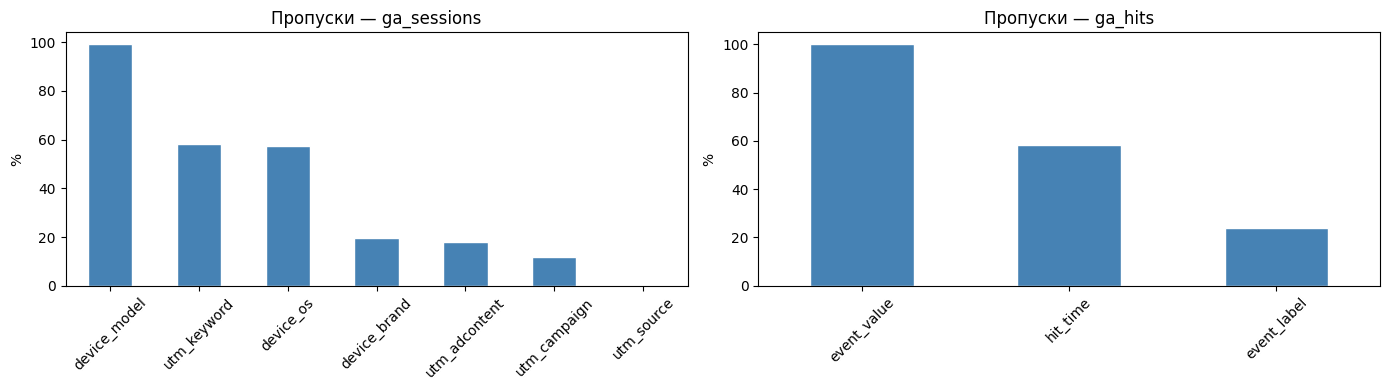

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (df, name) in zip(axes, [(sessions, "ga_sessions"), (hits, "ga_hits")]):
    miss_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    miss_pct = miss_pct[miss_pct > 0]
    if miss_pct.empty:
        ax.text(0.5, 0.5, "Нет пропусков", ha="center", va="center", fontsize=14)
    else:
        miss_pct.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Пропуски - {name}")
    ax.set_ylabel("%")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 3. Формирование целевой переменной

In [11]:
hits.event_category.value_counts()

event_category
card_web                         7456998
search_form                      2423605
sub_page_view                    1986074
sub_button_click                 1073471
listing_ads                      1040468
cars                              358915
sap_search_form                   356596
quiz                              263134
auth                              189373
sap_search__form                  188129
jivosite                           88443
chat                               85007
ad_banner                          40441
offers                             31218
navigation                         27075
footer                             20297
sub_submit                         18495
greenday_sub_button_click          15425
main_banners                       14142
profile_menu                       13879
scrolling_main_page                12160
active_invitation                   8478
header                              3531
my_idea                             2319
g

In [12]:
ea_counts = hits["event_action"].value_counts()
ea_counts.head(50).to_frame("count")

,count
event_action,
view_card,3558985
view_new_card,3551009
sub_landing,1798117
go_to_car_card,973666
sub_view_cars_click,791515
search_form_region,512069
search_form_search_btn,433748
sap_search_form_cost_to,356596
showed_number_ads,326274


In [13]:
ea_counts = hits["event_action"].value_counts()
ea_counts

event_action
view_card                                   3558985
view_new_card                               3551009
sub_landing                                 1798117
go_to_car_card                               973666
sub_view_cars_click                          791515
search_form_region                           512069
search_form_search_btn                       433748
sap_search_form_cost_to                      356596
showed_number_ads                            326274
pagination_click                             248944
search_form_mark_select                      222652
quiz_show                                    214037
search_form_model_select                     211890
sap_search_form_cost_from                    188129
photos_all                                   181493
search_form_search_car_type_select           174877
photos                                       158543
sub_car_page                                 130310
view_more_click                              109971

In [14]:
TARGET_ACTIONS = [
    "sub_submit_success",
    "sub_car_claim_submit_click",
    "sub_callback_submit_click",
    "sub_car_request_submit_click",
    "sub_call_number_click",
    "chat established",
    "chat requested",
    "greenday_sub_callback_submit_click",
    "greenday_sub_submit_success",
    "form_request_call_sent",
    "callback requested",
    "request_success",
    "click_on_request_call",
]
for action in TARGET_ACTIONS:
    cnt = ea_counts.get(action, 0)
    print(f"  {action}: {cnt:,}")
print(f"\nВсего целевых: {ea_counts[ea_counts.index.isin(TARGET_ACTIONS)].sum():,}")

  sub_submit_success: 18,439
  sub_car_claim_submit_click: 12,359
  sub_callback_submit_click: 3,074
  sub_car_request_submit_click: 2,966
  sub_call_number_click: 3,653
  chat established: 2,066
  chat requested: 2,114
  greenday_sub_callback_submit_click: 950
  greenday_sub_submit_success: 698
  form_request_call_sent: 34
  callback requested: 41
  request_success: 4
  click_on_request_call: 50

Всего целевых: 46,448


Конверсионных сессий: 22,877
Всего: 1,860,042, конверсий: 22,641, CR=1.22%
Дисбаланс 0:1 = 81.2:1


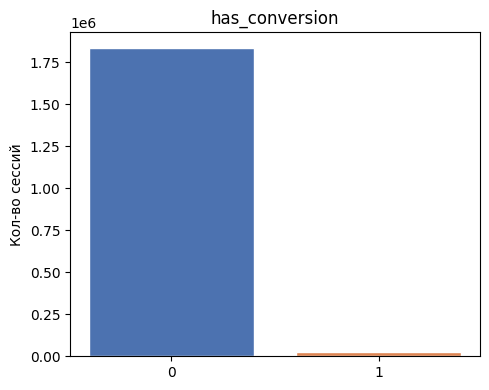

In [15]:
conversion_mask = hits["event_action"].isin(TARGET_ACTIONS)
conversion_sessions = (
    hits[conversion_mask]["session_id"]
    .drop_duplicates()
    .to_frame()
    .assign(has_conversion=1)
)
print(f"Конверсионных сессий: {len(conversion_sessions):,}")

df = sessions.merge(conversion_sessions, on="session_id", how="left")
df["has_conversion"] = df["has_conversion"].fillna(0).astype(int)

total = len(df)
conv = df["has_conversion"].sum()
print(f"Всего: {total:,}, конверсий: {conv:,}, CR={conv/total*100:.2f}%")
print(f"Дисбаланс 0:1 = {(total-conv)/conv:.1f}:1")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["0", "1"], [total - conv, conv], color=["#4C72B0", "#DD8452"], edgecolor="white")
ax.set_title("has_conversion")
ax.set_ylabel("Кол-во сессий")
plt.tight_layout()
plt.show()

## 4. Агрегация признаков из хитов на уровень сессии

In [16]:
hits_agg = hits.groupby("session_id").agg(
    total_hits=("event_action", "count"),
).reset_index()

car_pages = (
    hits[hits["hit_page_path"].fillna("").str.contains("/car", case=False, na=False)]
    ["session_id"].drop_duplicates().to_frame().assign(is_car_page=1)
)

conv_hit_paths = (
    hits[hits["event_action"].isin(TARGET_ACTIONS)]
    ["hit_page_path"].fillna("(пусто)").str.split("?").str[0]
    .value_counts().head(5)
)
print("Топ-5 страниц с целевыми событиями:")
print(conv_hit_paths.to_string())

hits_sorted = hits.sort_values(["session_id", "hit_number"])
hits_sorted["next_action"] = hits_sorted.groupby("session_id")["event_action"].shift(-1)
pre_conv = hits_sorted[hits_sorted["next_action"].isin(TARGET_ACTIONS)]
top_pre_conv_cat = pre_conv["event_category"].value_counts().head(3)
print("\nТоп-3 event_category перед конверсией:")
print(top_pre_conv_cat.to_string())

df = df.merge(hits_agg, on="session_id", how="left")
df = df.merge(car_pages, on="session_id", how="left")
df["total_hits"] = df["total_hits"].fillna(0).astype(int)
df["is_car_page"] = df["is_car_page"].fillna(0).astype(int)

print(f"\ndf shape: {df.shape}")
df.head(3)

Топ-5 страниц с целевыми событиями:
hit_page_path
podpiska.sberauto.com/                           6323
sberauto.com/cars                                4413
sberauto.com/cars/all/skoda/rapid/bf24b977       2687
sberauto.com/cars/f28947a1                       2414
sberauto.com/cars/all/lada-vaz/vesta/2fc745ed    2295

Топ-3 event_category перед конверсией:
event_category
sub_button_click    37588
jivosite             1712
auth                 1640

df shape: (1860042, 21)


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,...,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city,has_conversion,total_hits,is_car_page
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust,0,2,0
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,...,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow,0,1,0
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,...,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk,0,16,1


## 5. Анализ распределений и конверсия по категориям

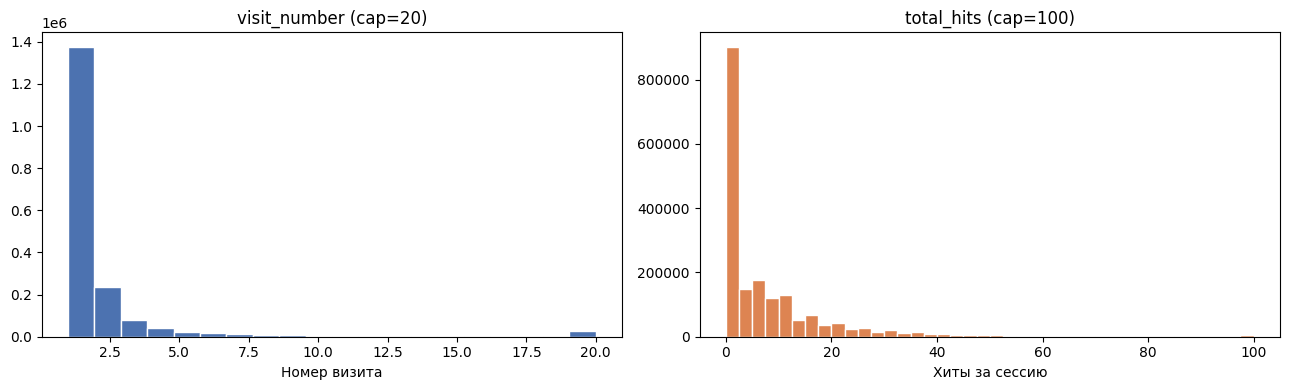

visit_number: медиана=1.0, среднее=2.7
total_hits:   медиана=3.0, среднее=8.4


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["visit_number"].clip(upper=20), bins=20, color="#4C72B0", edgecolor="white")
axes[0].set_title("visit_number (cap=20)")
axes[0].set_xlabel("Номер визита")

axes[1].hist(df["total_hits"].clip(upper=100), bins=40, color="#DD8452", edgecolor="white")
axes[1].set_title("total_hits (cap=100)")
axes[1].set_xlabel("Хиты за сессию")

plt.tight_layout()
plt.show()

print(f"visit_number: медиана={df['visit_number'].median()}, среднее={df['visit_number'].mean():.1f}")
print(f"total_hits:   медиана={df['total_hits'].median()}, среднее={df['total_hits'].mean():.1f}")

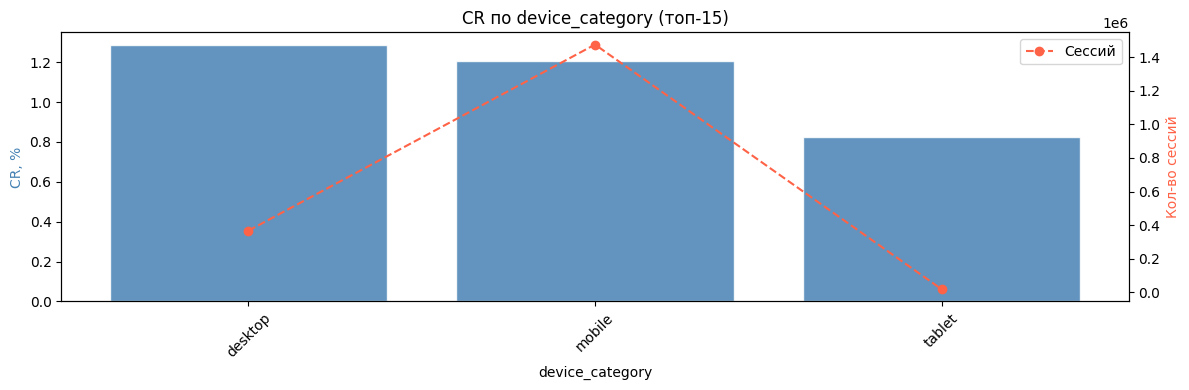

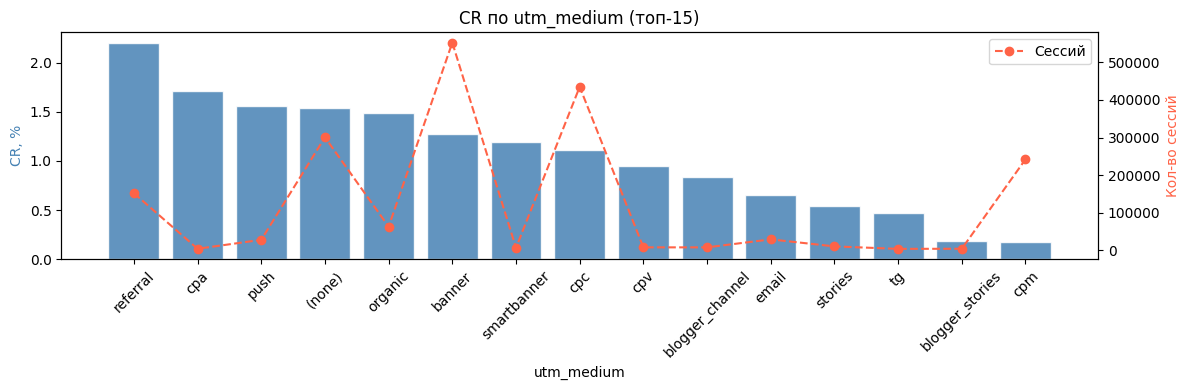

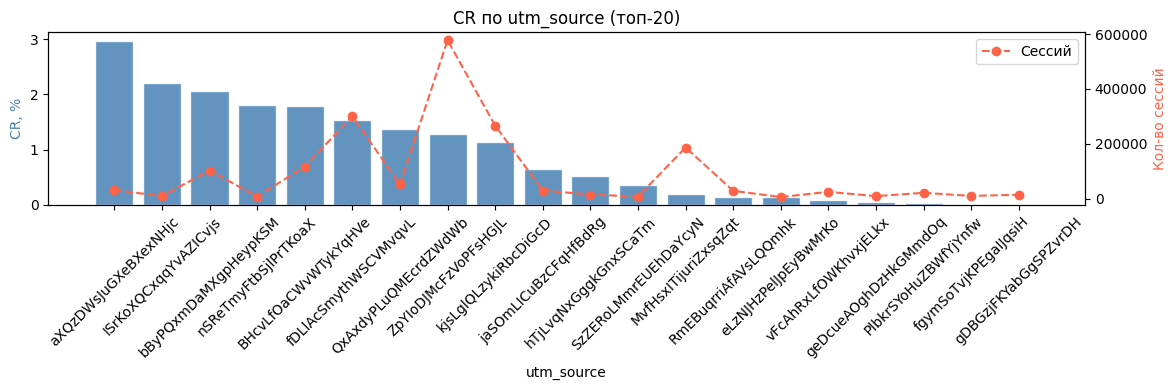

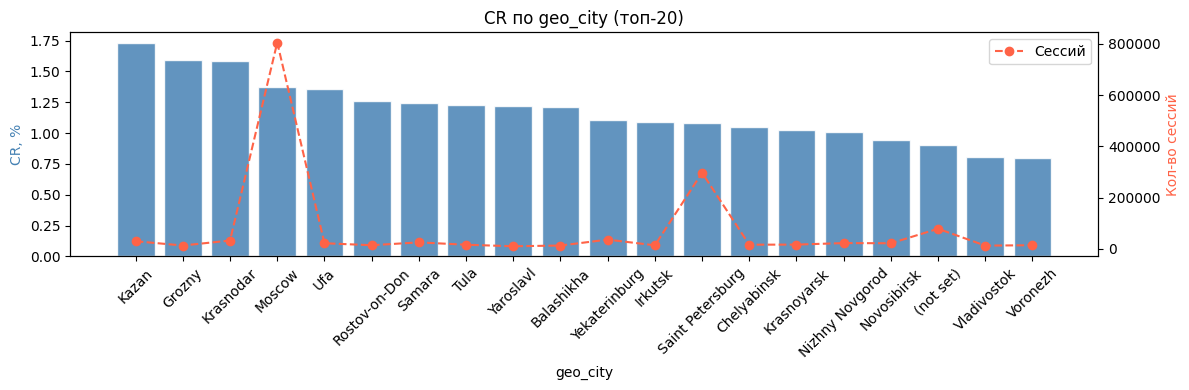

In [18]:
def plot_cr_by_category(df, col, top_n=20, figsize=(12, 4), title=None):
    agg = (
        df.groupby(col)["has_conversion"]
        .agg(sessions="count", conversions="sum")
        .assign(cr=lambda x: x["conversions"] / x["sessions"] * 100)
        .sort_values("sessions", ascending=False)
        .head(top_n)
        .sort_values("cr", ascending=False)
    )
    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.bar(agg.index.astype(str), agg["cr"], color="steelblue", edgecolor="white", alpha=0.85)
    ax2 = ax1.twinx()
    ax2.plot(agg.index.astype(str), agg["sessions"], "o--", color="tomato", label="Сессий")
    ax1.set_title(title or f"CR по {col} (топ-{top_n})", fontsize=12)
    ax1.set_ylabel("CR, %", color="steelblue")
    ax1.set_xlabel(col)
    ax2.set_ylabel("Кол-во сессий", color="tomato")
    ax1.tick_params(axis="x", rotation=45)
    ax2.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

for col in ["device_category", "utm_medium", "utm_source", "geo_city"]:
    plot_cr_by_category(df, col, top_n=20 if col in ["utm_source", "geo_city"] else 15)

## 6. Временной анализ

               hour   day_of_week         month    is_weekend
count  1.860042e+06  1.860042e+06  1.860042e+06  1.860042e+06
mean   1.361912e+01  2.799550e+00  9.326662e+00  2.430639e-01
std    6.121915e+00  1.983562e+00  2.199771e+00  4.289335e-01
min    0.000000e+00  0.000000e+00  5.000000e+00  0.000000e+00
25%    1.000000e+01  1.000000e+00  8.000000e+00  0.000000e+00
50%    1.400000e+01  3.000000e+00  1.000000e+01  0.000000e+00
75%    1.900000e+01  4.000000e+00  1.100000e+01  0.000000e+00
max    2.300000e+01  6.000000e+00  1.200000e+01  1.000000e+00


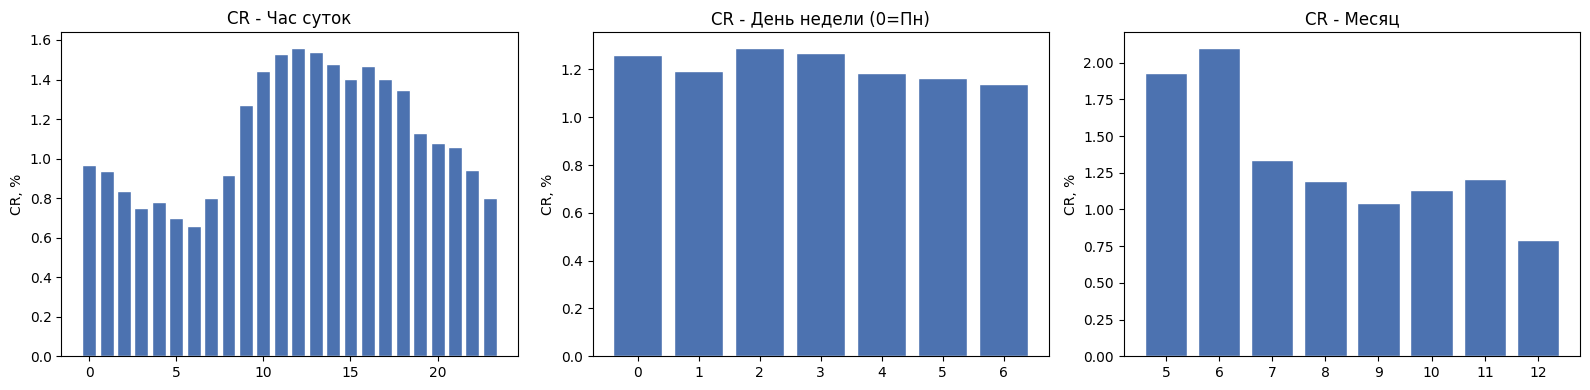

In [19]:
df["visit_date_dt"] = pd.to_datetime(df["visit_date"], errors="coerce")

def parse_hour(t):
    try:
        if isinstance(t, str) and ":" in t:
            return int(t.split(":")[0])
        val = float(t)
        return int(val // 3600) % 24
    except (ValueError, TypeError):
        return np.nan

df["hour"] = df["visit_time"].apply(parse_hour)
df["day_of_week"] = df["visit_date_dt"].dt.dayofweek
df["month"] = df["visit_date_dt"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

print(df[["hour", "day_of_week", "month", "is_weekend"]].describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, label in zip(
    axes,
    ["hour", "day_of_week", "month"],
    ["Час суток", "День недели (0=Пн)", "Месяц"]
):
    cr_time = df.groupby(col)["has_conversion"].agg(sessions="count", cr=lambda x: x.mean() * 100)
    ax.bar(cr_time.index, cr_time["cr"], color="#4C72B0", edgecolor="white")
    ax.set_title(f"CR - {label}")
    ax.set_ylabel("CR, %")

plt.tight_layout()
plt.show()

Видна зависимость конверсии от времени суток, месяца года

## 7. Корреляция (Пирсон) и Cramér's V

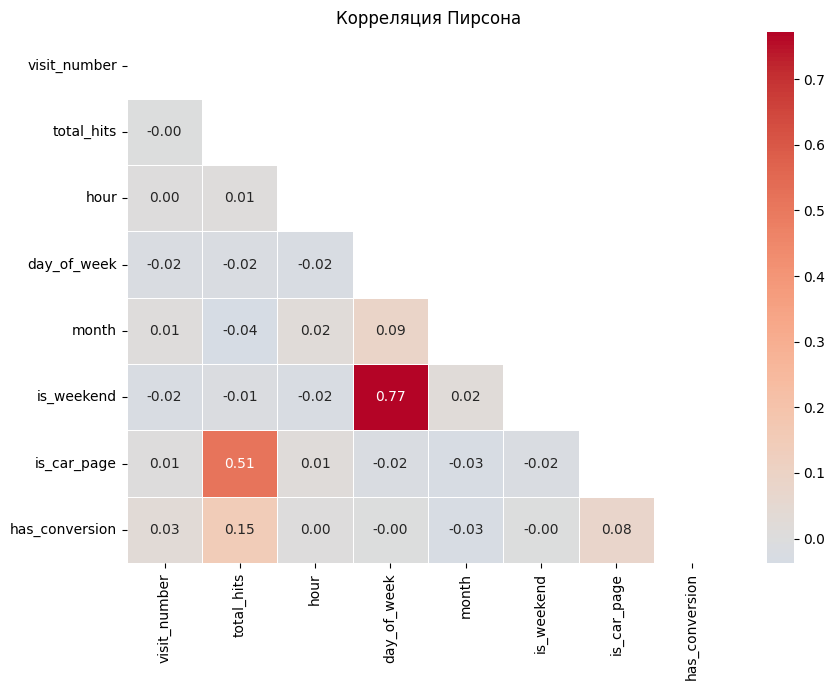

=== Cramér's V с has_conversion ===
utm_medium         0.0596
utm_source         0.0582
geo_city           0.0378
device_os          0.0210
geo_country        0.0136
device_category    0.0046


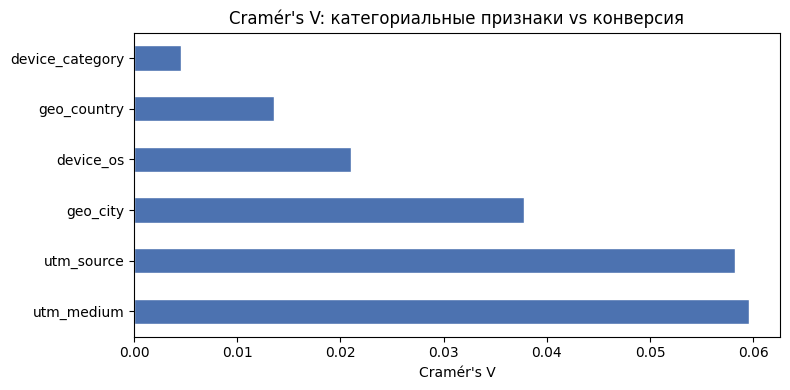

In [20]:
from scipy.stats import chi2_contingency

num_cols_eda = ["visit_number", "total_hits", "hour", "day_of_week", "month",
                "is_weekend", "is_car_page", "has_conversion"]
corr_df = df[num_cols_eda].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, annot=True, fmt=".2f", mask=mask,
            cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Корреляция Пирсона")
plt.tight_layout()
plt.show()

def cramers_v(col_a, col_b):
    ct = pd.crosstab(col_a, col_b)
    chi2 = chi2_contingency(ct)[0]
    n = ct.values.sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k)) if (n * k) > 0 else 0.0

cat_cols_eda = ["device_category", "device_os", "utm_medium", "utm_source", "geo_country", "geo_city"]
cv_vals = {}
for col in cat_cols_eda:
    cv_vals[col] = round(cramers_v(df[col].fillna("unknown"), df["has_conversion"].astype(str)), 4)

cv_series = pd.Series(cv_vals).sort_values(ascending=False)
print("=== Cramér's V с has_conversion ===")
print(cv_series.to_string())

plt.figure(figsize=(8, 4))
cv_series.plot(kind="barh", color="#4C72B0", edgecolor="white")
plt.title("Cramér's V: категориальные признаки vs конверсия")
plt.xlabel("Cramér's V")
plt.tight_layout()
plt.show()

## 8. Анализ поведения: длина сессии и топ страниц

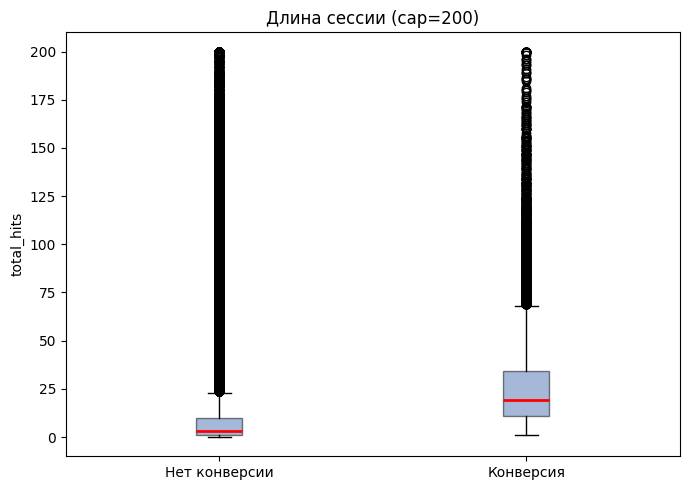

Медиана total_hits:
has_conversion
0     3.0
1    19.0
Name: total_hits, dtype: float64


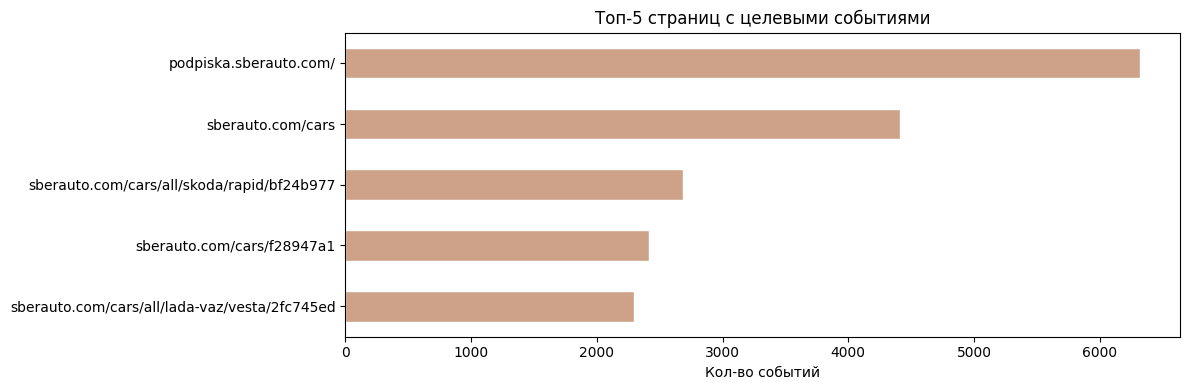

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
groups = [
    df[df["has_conversion"] == 0]["total_hits"].clip(upper=200),
    df[df["has_conversion"] == 1]["total_hits"].clip(upper=200),
]
ax.boxplot(groups, labels=["Нет конверсии", "Конверсия"],
           patch_artist=True,
           boxprops=dict(facecolor="#4C72B0", alpha=0.5),
           medianprops=dict(color="red", linewidth=2))
ax.set_title("Длина сессии (cap=200)")
ax.set_ylabel("total_hits")
plt.tight_layout()
plt.show()

print("Медиана total_hits:")
print(df.groupby("has_conversion")["total_hits"].median())

fig, ax = plt.subplots(figsize=(12, 4))
top_paths = conv_hit_paths.sort_values()
top_paths.index = [p[:70] + "..." if len(p) > 70 else p for p in top_paths.index]
top_paths.plot(kind="barh", ax=ax, color="#CEA288", edgecolor="white")
ax.set_title("Топ-5 страниц с целевыми событиями")
ax.set_xlabel("Кол-во событий")
plt.tight_layout()
plt.show()

### Выводы EDA

- `total_hits` хорошо разделяет классы: конверсионные сессии в среднем в 6 раз длиннее
- Просмотр карточки авто (`/car/`) сильно повышает вероятность заявки
- Платный трафик дает основной объём, но конверсия заметно зависит от конкретного источника
- Рабочие часы (10-18) конверсионнее вечерних и ночных
- По Cramér's V: `utm_source` и `geo_city` сильнее всего связаны с конверсией

## 9. Feature Engineering

In [22]:
df_fe = df.copy()

df_fe["is_mobile"] = (df_fe["device_category"].str.lower() == "mobile").astype(int)
df_fe["visit_number_gt1"] = (df_fe["visit_number"] > 1).astype(int)

# utm_source анонимизирован хешами - используем только utm_medium
ORGANIC_MEDIUMS = {"organic", "referral", "(none)", "none", ""}

def classify_utm_medium(medium):
    m = str(medium or "").lower().strip()
    if m in ORGANIC_MEDIUMS or m == "nan":
        return "organic"
    if m in {"cpc", "cpm", "paid", "paidsearch", "ppc"}:
        return "paid"
    return "other"

df_fe["utm_medium_group"] = df_fe["utm_medium"].apply(classify_utm_medium)
print("utm_medium_group:")
print(df_fe["utm_medium_group"].value_counts())

top_cities = df_fe["geo_city"].value_counts().head(20).index
top_models = df_fe["device_model"].value_counts().head(20).index

df_fe["geo_city_grp"] = df_fe["geo_city"].where(df_fe["geo_city"].isin(top_cities), other="other")
df_fe["device_model_grp"] = df_fe["device_model"].where(df_fe["device_model"].isin(top_models), other="other")

df_fe = df_fe.sort_values("visit_date_dt")

# rolling_cr_7d считаем по utm_medium_group (source анонимизирован)
daily_conv = (
    df_fe.groupby(["utm_medium_group", "visit_date_dt"])["has_conversion"]
    .mean().reset_index().rename(columns={"has_conversion": "daily_cr"})
)
daily_conv = daily_conv.sort_values(["utm_medium_group", "visit_date_dt"])
daily_conv["rolling_cr_7d"] = (
    daily_conv.groupby("utm_medium_group")["daily_cr"]
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)

df_fe = df_fe.merge(
    daily_conv[["utm_medium_group", "visit_date_dt", "rolling_cr_7d"]],
    on=["utm_medium_group", "visit_date_dt"], how="left"
)
df_fe["rolling_cr_7d"] = df_fe["rolling_cr_7d"].fillna(df_fe["rolling_cr_7d"].median())

print(f"\ndf_fe shape: {df_fe.shape}")


utm_medium_group:
utm_medium_group
paid       676917
other      667466
organic    515659
Name: count, dtype: int64

df_fe shape: (1860042, 32)


## 10. Препроцессинг-пайплайн

In [23]:
NUMERIC_FEATURES = [
    "visit_number", "total_hits", "hour", "day_of_week", "month",
    "is_mobile", "is_weekend", "visit_number_gt1", "is_car_page", "rolling_cr_7d",
]

OHE_FEATURES = [
    "device_category",
    "utm_medium_group",
    "device_os",
    "device_browser",
]

HIGH_CARD_FEATURES = [
    "geo_city_grp",
    "device_model_grp",
]

FEATURE_COLS = NUMERIC_FEATURES + OHE_FEATURES + HIGH_CARD_FEATURES
TARGET_COL = "has_conversion"

for col in OHE_FEATURES + HIGH_CARD_FEATURES:
    df_fe[col] = df_fe[col].fillna("unknown")
for col in NUMERIC_FEATURES:
    df_fe[col] = df_fe[col].fillna(df_fe[col].median())

X = df_fe[FEATURE_COLS].copy()
y = df_fe[TARGET_COL].copy()
print(f"X: {X.shape}, y: {y.shape}")
print(f"Баланс: {y.mean():.4f} ({y.sum():,} из {len(y):,})")


X: (1860042, 16), y: (1860042,)
Баланс: 0.0122 (22,641 из 1,860,042)


In [24]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

ohe_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

high_card_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=100)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num",      numeric_pipeline,   NUMERIC_FEATURES),
        ("ohe",      ohe_pipeline,       OHE_FEATURES),
        ("high_ohe", high_card_pipeline, HIGH_CARD_FEATURES),
    ],
    remainder="drop"
)

## 11. Разделение выборки

In [25]:
df_fe_sorted = df_fe.sort_values("visit_date_dt")
split_idx = int(len(df_fe_sorted) * 0.8)
split_date = df_fe_sorted["visit_date_dt"].iloc[split_idx]
print(f"Граница сплита по дате: {split_date.date()}")

train_mask = df_fe_sorted["visit_date_dt"] < split_date
X_train = df_fe_sorted.loc[train_mask, FEATURE_COLS]
X_test = df_fe_sorted.loc[~train_mask, FEATURE_COLS]
y_train = df_fe_sorted.loc[train_mask, TARGET_COL]
y_test = df_fe_sorted.loc[~train_mask, TARGET_COL]

print(f"Train: {X_train.shape[0]:,} | конверсия: {y_train.mean():.4f}")
print(f"Test:  {X_test.shape[0]:,}  | конверсия: {y_test.mean():.4f}")

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
SPW = neg / pos
print(f"\nscale_pos_weight = {SPW:.2f}  (neg={neg:,}, pos={pos:,})")

Граница сплита по дате: 2021-12-03
Train: 1,487,559 | конверсия: 0.0133
Test:  372,483  | конверсия: 0.0079

scale_pos_weight = 74.46  (neg=1,467,846, pos=19,713)


## 12. Обучение базовых моделей

In [26]:
results = {}

def train_and_evaluate(name, model, X_tr, y_tr, X_te, y_te):
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_tr, y_tr)
    proba = pipe.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, proba)
    pr_auc = average_precision_score(y_te, proba)
    print(f"{name:35s}  ROC-AUC={auc:.4f}  PR-AUC={pr_auc:.4f}")
    results[name] = {"model": pipe, "proba": proba, "auc": auc, "pr_auc": pr_auc}
    return pipe

print("=== Базовые модели ===\n")

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
train_and_evaluate("DummyClassifier (most_frequent)", dummy, X_train, y_train, X_test, y_test)

lr = LogisticRegression(class_weight="balanced", max_iter=1000, C=0.1,
                        solver="lbfgs", random_state=RANDOM_STATE)
train_and_evaluate("LogisticRegression (balanced)", lr, X_train, y_train, X_test, y_test)

rf = RandomForestClassifier(n_estimators=100, max_depth=8,
                            class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)
train_and_evaluate("RandomForest (n=100, d=8)", rf, X_train, y_train, X_test, y_test)

lgbm_base = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=63,
    scale_pos_weight=SPW, n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
)
train_and_evaluate("LightGBM (base)", lgbm_base, X_train, y_train, X_test, y_test)

=== Базовые модели ===

DummyClassifier (most_frequent)      ROC-AUC=0.5000  PR-AUC=0.0079
LogisticRegression (balanced)        ROC-AUC=0.8468  PR-AUC=0.0488
RandomForest (n=100, d=8)            ROC-AUC=0.8698  PR-AUC=0.0495
LightGBM (base)                      ROC-AUC=0.8927  PR-AUC=0.0502


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 13. Подбор гиперпараметров (LightGBM)

In [27]:
from scipy.stats import randint, uniform

N_ITER = 15
CV = 4

print(f"RandomizedSearchCV ({N_ITER} iter, {CV}-fold) ...")

param_dist = {
    "model__num_leaves":        randint(31, 128),
    "model__learning_rate":     uniform(0.01, 0.15),
    "model__n_estimators":      randint(200, 600),
    "model__subsample":         uniform(0.6, 0.4),
    "model__colsample_bytree":  uniform(0.6, 0.4),
    "model__min_child_samples": randint(20, 100),
    "model__reg_alpha":         uniform(0, 0.5),
    "model__reg_lambda":        uniform(0, 0.5),
}

lgbm_tuned_base = lgb.LGBMClassifier(
    scale_pos_weight=SPW, n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
)
pipe_to_tune = Pipeline([
    ("preprocessor", preprocessor),
    ("model", lgbm_tuned_base),
])

cv = StratifiedKFold(n_splits=CV, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    pipe_to_tune, param_distributions=param_dist,
    n_iter=N_ITER, scoring="roc_auc", cv=cv,
    n_jobs=1, random_state=RANDOM_STATE, verbose=1, refit=True,
)
search.fit(X_train, y_train)

print(f"\nЛучшие параметры: {search.best_params_}")
print(f"CV ROC-AUC: {search.best_score_:.4f}")

best_model = search.best_estimator_
proba_tuned = best_model.predict_proba(X_test)[:, 1]
auc_tuned = roc_auc_score(y_test, proba_tuned)
pr_auc_tuned = average_precision_score(y_test, proba_tuned)
print(f"Test ROC-AUC: {auc_tuned:.4f}, PR-AUC: {pr_auc_tuned:.4f}")

results["LightGBM (tuned)"] = {
    "model": best_model, "proba": proba_tuned,
    "auc": auc_tuned, "pr_auc": pr_auc_tuned
}

RandomizedSearchCV (15 iter, 4-fold) ...
Fitting 4 folds for each of 15 candidates, totalling 60 fits

Лучшие параметры: {'model__colsample_bytree': np.float64(0.7599443886861021), 'model__learning_rate': np.float64(0.016999849482042313), 'model__min_child_samples': 79, 'model__n_estimators': 470, 'model__num_leaves': 92, 'model__reg_alpha': np.float64(0.0453032172664104), 'model__reg_lambda': np.float64(0.30919300466654365), 'model__subsample': np.float64(0.7529847965068651)}
CV ROC-AUC: 0.9033
Test ROC-AUC: 0.8998, PR-AUC: 0.0540


## 14. Оценка качества моделей

In [28]:
summary = pd.DataFrame([
    {"Модель": name, "ROC-AUC": v["auc"], "PR-AUC": v["pr_auc"]}
    for name, v in results.items()
]).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

display(summary)

if summary["ROC-AUC"].max() >= 0.65:
    print("ROC-AUC >= 0.65")

,Модель,ROC-AUC,PR-AUC
0,LightGBM (tuned),0.899830,0.053956
1,LightGBM (base),0.892680,0.050242
2,"RandomForest (n=100, d=8)",0.869753,0.049457
3,LogisticRegression (balanced),0.846773,0.048794
4,DummyClassifier (most_frequent),0.500000,0.007861


ROC-AUC >= 0.65


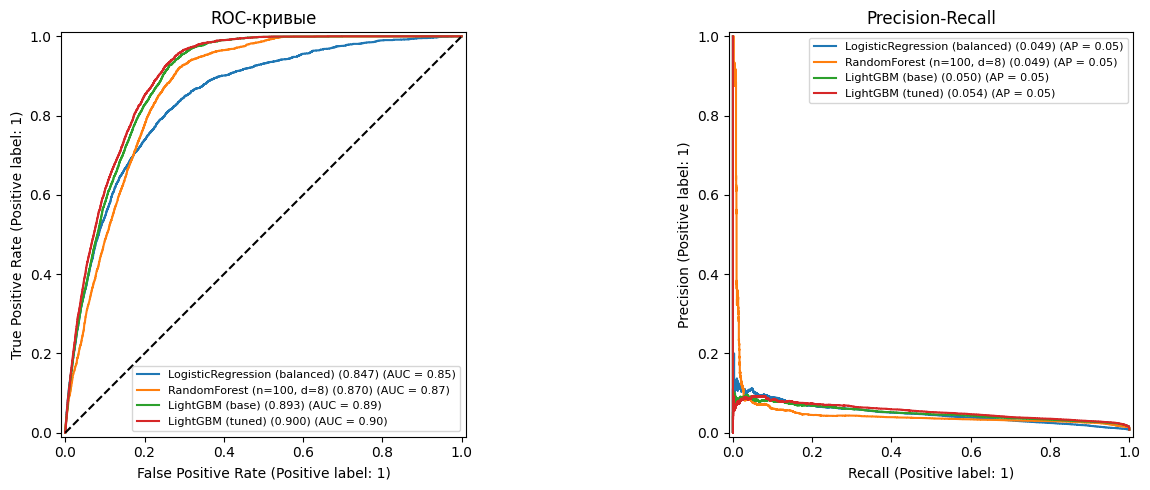


=== LightGBM (tuned) ===
              precision    recall  f1-score   support

           0     0.9986    0.7907    0.8826    369555
           1     0.0316    0.8627    0.0610      2928

    accuracy                         0.7913    372483
   macro avg     0.5151    0.8267    0.4718    372483
weighted avg     0.9910    0.7913    0.8761    372483



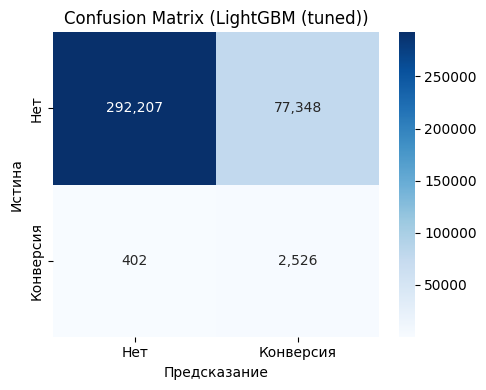

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, v in results.items():
    if name == "DummyClassifier (most_frequent)":
        continue
    RocCurveDisplay.from_predictions(
        y_test, v["proba"], name=f"{name} ({v['auc']:.3f})", ax=axes[0]
    )
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("ROC-кривые")
axes[0].legend(fontsize=8)

for name, v in results.items():
    if name == "DummyClassifier (most_frequent)":
        continue
    PrecisionRecallDisplay.from_predictions(
        y_test, v["proba"], name=f"{name} ({v['pr_auc']:.3f})", ax=axes[1]
    )
axes[1].set_title("Precision-Recall")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

best_name = summary.iloc[0]["Модель"]
best_proba = results[best_name]["proba"]
best_pred = (best_proba >= 0.5).astype(int)
print(f"\n=== {best_name} ===")
print(classification_report(y_test, best_pred, digits=4))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=["Нет", "Конверсия"],
            yticklabels=["Нет", "Конверсия"])
plt.title(f"Confusion Matrix ({best_name})")
plt.ylabel("Истина")
plt.xlabel("Предсказание")
plt.tight_layout()
plt.show()

## 15. Интерпретация: Feature Importance

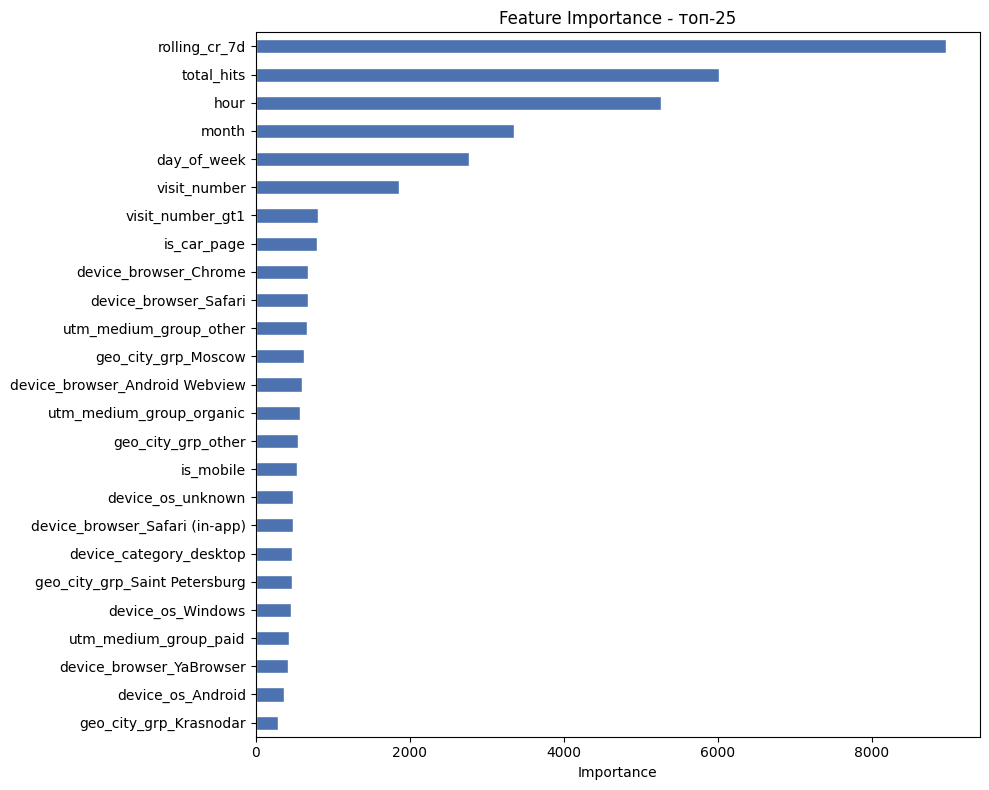

In [35]:
final_pipe = results[best_name]["model"]

def get_feature_names(ct):
    names = []
    for name, trans, cols in ct.transformers_:
        if name == "remainder":
            continue
        if hasattr(trans, "steps"):
            last_step = trans.steps[-1][1]
            if hasattr(last_step, "get_feature_names_out"):
                names.extend(last_step.get_feature_names_out(cols))
            else:
                names.extend(cols)
        else:
            names.extend(cols)
    return names

feat_names = get_feature_names(final_pipe.named_steps["preprocessor"])
lgbm_model = final_pipe.named_steps["model"]

fi = pd.Series(lgbm_model.feature_importances_, index=feat_names)
fi = fi.sort_values(ascending=False).head(25)

plt.figure(figsize=(10, 8))
fi.sort_values().plot(kind="barh", color="#4C72B0", edgecolor="white")
plt.title("Feature Importance - топ-25")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Выводы

`total_hits` - значимый предиктор: длинные сессии конвертируются в 6 раз чаще. Просмотр карточки авто значительно повышает вероятность заявки. Повторные визиты тоже.

`rolling_cr_7d` - топ1 среди признаков - каналы с исторически высоким CR остаются эффективными.

Мобильные: больше половины трафика, но конверсия ниже. Стоит упростить форму заявки.

Часы: конверсия выше в 10-18 в будни.

Пользователи посетившие `/car/` без заявки - очевидная аудитория для ремаркетинга.

## 17. Сохранение модели и препроцессора

In [36]:
model_path = os.path.join(MODELS_DIR, "final_model.pkl")
preprocessor_path = os.path.join(MODELS_DIR, "preprocessor.pkl")
meta_path = os.path.join(MODELS_DIR, "feature_config.pkl")

joblib.dump(final_pipe, model_path)
joblib.dump(final_pipe.named_steps["preprocessor"], preprocessor_path)

meta = {
    "feature_cols":       FEATURE_COLS,
    "numeric_features":   NUMERIC_FEATURES,
    "ohe_features":       OHE_FEATURES,
    "high_card_features": HIGH_CARD_FEATURES,
    "target_actions":     TARGET_ACTIONS,
    "best_model_name":    best_name,
    "test_roc_auc":       results[best_name]["auc"],
    "top_cities":         top_cities.tolist(),
}
joblib.dump(meta, meta_path)

print(f"Сохранено: {model_path}")

loaded_pipe = joblib.load(model_path)
test_proba = loaded_pipe.predict_proba(X_test.head(5))[:, 1]
print(f"Проверка: {test_proba.round(4)}")

Сохранено: ../models/final_model.pkl
Проверка: [2.000e-04 9.000e-04 2.200e-03 3.500e-03 4.333e-01]
